# Analysis model VGG / VGGFusion

This notebook allows you to load a trained VGG checkpoint, evaluate it on the test set, and visualize the results.

In [1]:
import sys
import os
import torch
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec
import numpy as np

# Fix ModuleNotFoundError: No module named 'src'
if os.path.abspath(os.getcwd()) not in sys.path:
    sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.models import get_model
from src.data.dataloader import build_dataloader 
from src.evaluation.evaluator import evaluate_and_show
from src.utils.config import load_config           

print("Imports successful!")

Imports successful!


## 1. Configuration

Specify the paths to your config file and checkpoint file.

In [2]:
# CONFIG_PATH: Tên file config (không cần đuôi .yaml)
MODEL_NAME_CONFIG = "vgg_fusion_48x48x1"

# Môi trường chạy: 'local' hoặc 'kaggle'
ENV = 'local' 

# LOAD CONFIG
config = load_config(model=MODEL_NAME_CONFIG, env=ENV)

def fix_path(path):
    """Helper to fix relative paths when running from notebooks folder"""
    if not os.path.isabs(path) and not os.path.exists(path):
        potential_path = os.path.join("..", path)
        if os.path.exists(potential_path):
            return potential_path
    return path

# CHECKPOINT_PATH: Đường dẫn file .pth
CHECKPOINT_PATH = fix_path(os.path.join(config['output_dir'], "checkpoints/vgg_fusion/vgg_fusion_04042026_1747_best.pth"))

# SAVE_DIR: Nơi lưu ảnh kết quả
SAVE_DIR = fix_path(os.path.join(config['output_dir'], "evaluation/vgg_fusion/"))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Checkpoint path: {CHECKPOINT_PATH}")

Using device: cuda
Checkpoint path: ..\outputs\checkpoints/vgg_fusion/vgg_fusion_04042026_1747_best.pth


## 2. Load Model & Data

In [3]:
# 2.1 Load Model
print(f"Loading model architecture: {config['model']['name']}")
model = get_model(config['model']['name'], config=config)

if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Weights loaded successfully from {CHECKPOINT_PATH}!")
else:
    print(f"WARNING: Checkpoint not found at {CHECKPOINT_PATH}. Running with initial weights.")

model.to(device)
model.eval()
print("Model is ready on device.")

Loading model architecture: vgg_fusion
Weights loaded successfully from ..\outputs\checkpoints/vgg_fusion/vgg_fusion_04042026_1747_best.pth!
Model is ready on device.


In [4]:
# 2.2 Load Data
data_path = fix_path(config['data_path'])

print(f"Building dataloader from: {data_path}")
_, _, test_loader = build_dataloader(config, data_path)
print(f"Test set size: {len(test_loader.dataset)} samples")

Building dataloader from: ..\dataset/fer13-split
Test set size: 3589 samples


## 3. Run Evaluation

This will calculate metrics and generate images (`confusion_matrix.png`, `correct_preds.png`, `wrong_preds.png`) in the `SAVE_DIR`.

Evaluate test set...: 100%|██████████| 57/57 [00:07<00:00,  8.07it/s]



Pushing to WandB & Dashboard...
Compute metrics and confusion matrix...
--> Accuracy: 67.40%
--> Report:
               precision    recall  f1-score      support
angry          0.616000  0.627291  0.621594   491.000000
disgust        0.541176  0.836364  0.657143    55.000000
fear           0.531328  0.401515  0.457389   528.000000
happy          0.907563  0.860068  0.883178   879.000000
sad            0.557656  0.496633  0.525378   594.000000
surprise       0.704312  0.824519  0.759690   416.000000
neutral        0.607143  0.733227  0.664255   626.000000
accuracy       0.674004  0.674004  0.674004     0.674004
macro avg      0.637883  0.682802  0.652661  3589.000000
weighted avg   0.672840  0.674004  0.669571  3589.000000
--> Saved prediction grid to outputs\evaluation/vgg_fusion/correct_preds.png
--> Saved prediction grid to outputs\evaluation/vgg_fusion/wrong_preds.png
Done! Save file at: outputs\evaluation/vgg_fusion/


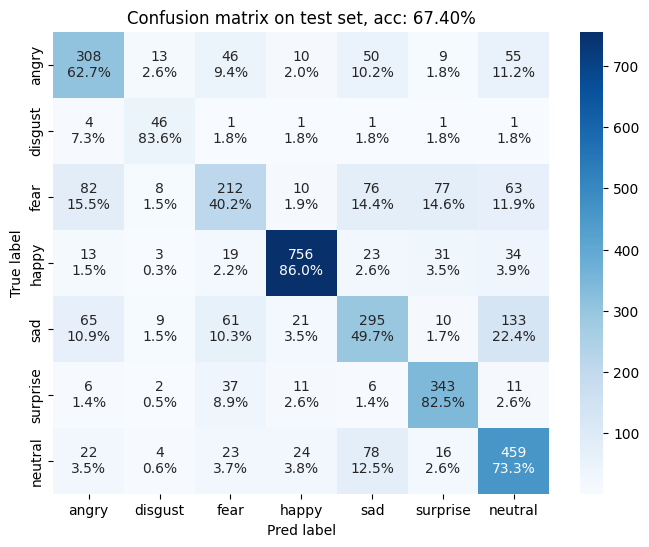

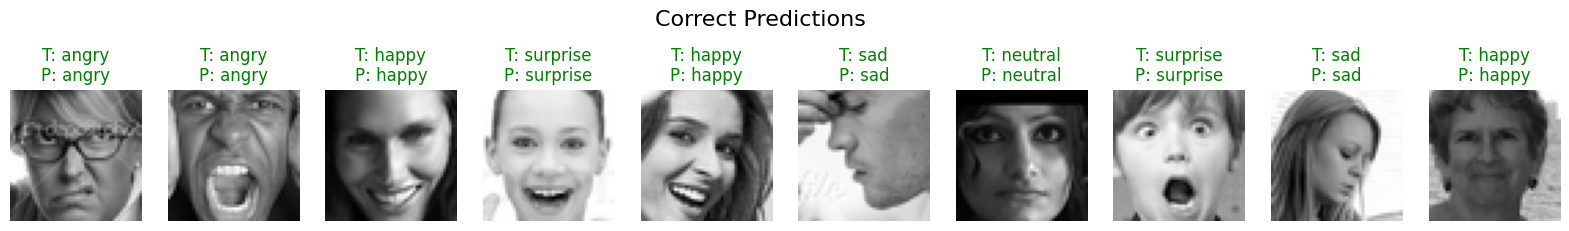

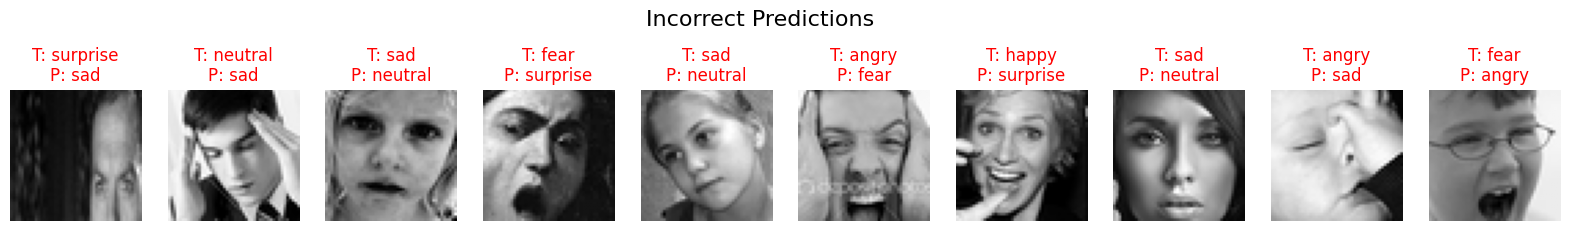

In [5]:
evaluate_and_show(
    model=model, 
    test_loader=test_loader, 
    testset_path=data_path, 
    device=device, 
    save_dir=SAVE_DIR
)

## 4. Visualize Results

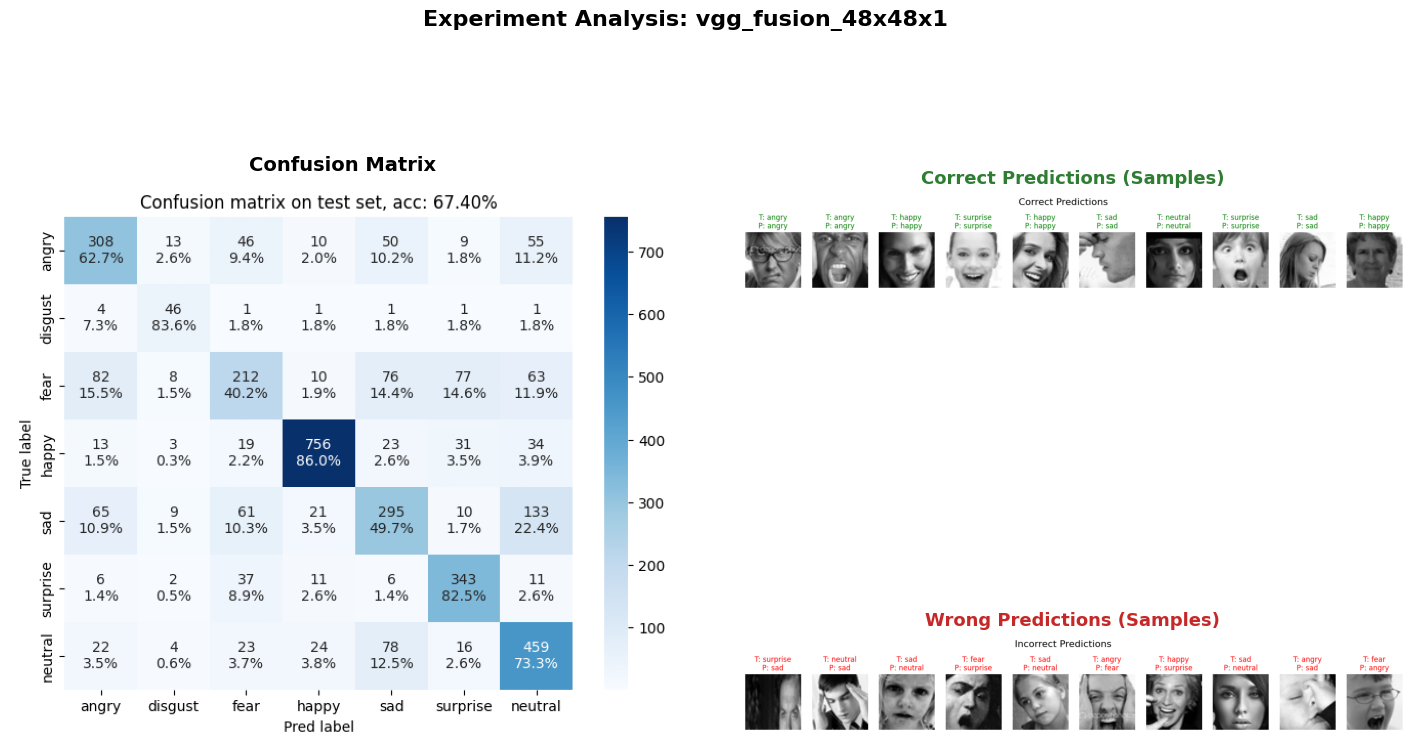

In [6]:
def plot_cm_preds_image(ver_exp_path):
    # Load images
    cm_path      = os.path.join(ver_exp_path, "confusion_matrix.png")
    correct_path = os.path.join(ver_exp_path, "correct_preds.png")
    wrong_path   = os.path.join(ver_exp_path, "wrong_preds.png")

    if not all(os.path.exists(p) for p in [cm_path, correct_path, wrong_path]):
        print(f"One or more images not found in {ver_exp_path}. Run evaluation first!")
        return

    cm_img      = mpimg.imread(cm_path)
    correct_img = mpimg.imread(correct_path)
    wrong_img   = mpimg.imread(wrong_path)

    # Layout: 1 row × 2 cols, cột phải chia thành 2 hàng
    fig = plt.figure(figsize=(18, 10))
    gs = gridspec.GridSpec(
        nrows=2, ncols=2,
        figure=fig,
        hspace=0.35,   # khoảng cách dọc giữa 2 ô cột phải
        wspace=0.1,    # khoảng cách ngang giữa 2 cột
    )

    # Cột trái: confusion matrix chiếm cả 2 hàng
    ax_cm = fig.add_subplot(gs[:, 0])
    ax_cm.imshow(cm_img)
    ax_cm.set_title("Confusion Matrix", fontsize=14, fontweight="bold", pad=10)
    ax_cm.axis("off")

    # Cột phải – hàng trên: correct predictions
    ax_correct = fig.add_subplot(gs[0, 1])
    ax_correct.imshow(correct_img)
    ax_correct.set_title("Correct Predictions (Samples)", fontsize=13, fontweight="bold", pad=8, color="#2e7d32")
    ax_correct.axis("off")

    # Cột phải – hàng dưới: wrong predictions
    ax_wrong = fig.add_subplot(gs[1, 1])
    ax_wrong.imshow(wrong_img)
    ax_wrong.set_title("Wrong Predictions (Samples)", fontsize=13, fontweight="bold", pad=8, color="#c62828")
    ax_wrong.axis("off")

    fig.suptitle(f"Experiment Analysis: {MODEL_NAME_CONFIG}", fontsize=16, fontweight="bold", y=0.95)
    plt.show()

plot_cm_preds_image(SAVE_DIR)

Accuracy test: 67.4%
--> Với FER2013 + ảnh 48x48 + grayscale → khá ổn, nhưng vẫn còn room cải thiện (~70–72% là target tốt).

#  Experiment Analysis (VGG Fusion 48x48x1)

## 🔥 Tổng quan
- Accuracy: **67.4%** → khá tốt, còn cải thiện được

---

## 📌 Nhận xét chính

### ✅ Làm tốt
- Happy (86%)
- Surprise (82%)
👉 Biểu cảm rõ → dễ học

---

### ❌ Làm chưa tốt
- Fear (40%)
- Sad (49%)
👉 Biểu cảm mơ hồ, dễ nhầm

---

## ⚠️ Lỗi chính
- Nhầm giữa:
  - Angry ↔ Sad ↔ Neutral
  - Fear ↔ Surprise
- Sad vs Neutral là khó nhất

---

## 🚀 Hướng cải thiện
- Multi-scale feature fusion  
- Class balancing / Focal loss  
- Attention (focus mắt, miệng)  

---

## 📌 Kết luận
Model tốt với biểu cảm mạnh, yếu với cảm xúc tinh tế do feature overlap.